In [1]:
"""
  conda create -n CellDART python=3.8  
  conda activate CellDART  
  pip install git+https://github.com/mexchy1000/CellDART.git  
  python -m ipykernel install --user --name CellDART --display-name CellDART  
"""

import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import CellDART
from CellDART import da_cellfraction
from CellDART.utils import random_mix

import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score as ARI
from sklearn.metrics import normalized_mutual_info_score as NMI


### Specify paths

In [20]:

cell_type_col = "broad_cell_type"

sc_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Atlas/SC/SC_150000.h5ad"
results_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Atlas/simulator_outputs/ST_8/"

data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Atlas/simulator_outputs/ST_8/"

st_adata = sc.read_h5ad(data_path + "simulated_gene_expression_average.h5ad")
st_adata.obs_names_make_unique()
st_adata.var_names = pd.Categorical(st_adata.var_names).astype(str)
st_adata.var_names_make_unique()

### SC Step

In [4]:
sc_adata = sc.read_h5ad(sc_path)

sc_adata.obs_names_make_unique()
sc_adata.var_names = pd.Categorical(sc_adata.var_names).astype(str)
sc_adata.var_names_make_unique()

In [6]:
sc.__version__


'1.9.8'

/home/ajita/anaconda3/envs/CellDART/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/ajita/anaconda3/envs/CellDART/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


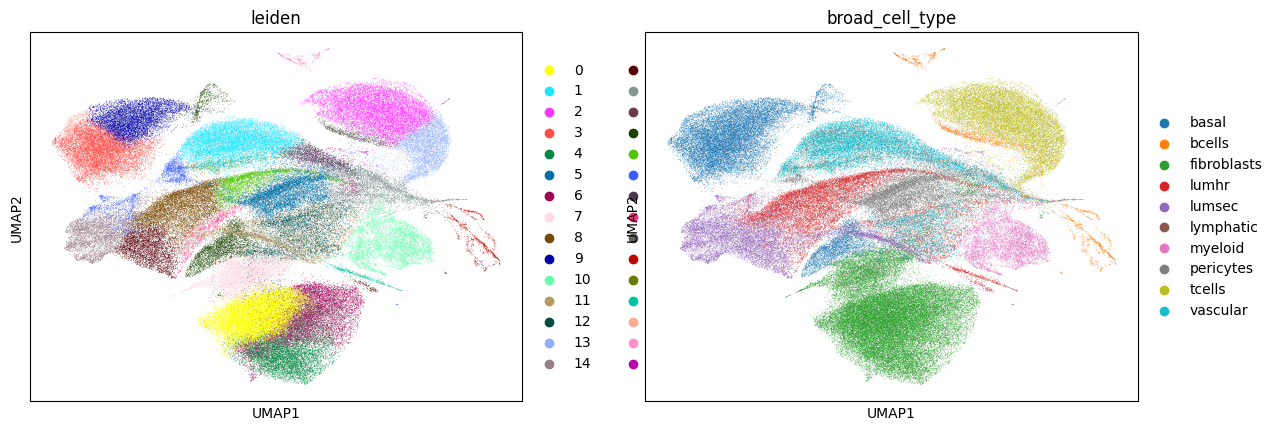

In [7]:
sc_adata.var['mt'] = sc_adata.var_names.str.startswith('Mt-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(sc_adata, qc_vars=['mt'], percent_top = None, log1p = False, inplace = True)
sc.pp.normalize_total(sc_adata, inplace = True)
sc.tl.pca(sc_adata, svd_solver='arpack')
sc.pp.neighbors(sc_adata, n_neighbors = 10, n_pcs = 40)
sc.tl.umap(sc_adata)
sc.tl.leiden(sc_adata, resolution = 1)
sc.pl.umap(sc_adata, color = ['leiden',cell_type_col])


In [9]:

sc.tl.rank_genes_groups(sc_adata, cell_type_col, method = 'wilcoxon')
#sc.pl.rank_genes_groups(sc_adata, n_genes=20, sharey = False)

/home/ajita/anaconda3/envs/CellDART/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/ajita/anaconda3/envs/CellDART/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


In [10]:

genelists = sc_adata.uns['rank_genes_groups']['names']

df_genelists = pd.DataFrame.from_records(genelists)

num_markers = 10
res_genes = []

for column in df_genelists.head(num_markers):
    res_genes.extend(df_genelists.head(num_markers)[column].tolist())
    
res_genes_ = list(set(res_genes))



### Select same gene feature between st_adata and sc_adata

In [22]:
sc.pp.filter_cells(st_adata, min_counts = 1, inplace = True)
sc.pp.filter_cells(st_adata, min_genes = 1, inplace = True)
sc.pp.normalize_total(st_adata, inplace = True)

inter_genes = [val for val in res_genes_ if val in st_adata.var.index]
print("Selected Feature Gene number:",len(inter_genes))
sc_adata = sc_adata[:,inter_genes]
st_adata = st_adata[:,inter_genes]

Selected Feature Gene number: 92


In [23]:
mat_sc = sc_adata.X.todense()
mat_sp = st_adata.X#.todense()
df_sc = sc_adata.obs

lab_sc_sub = df_sc[cell_type_col].values #broad_type #cell_type
sc_sub_dict = dict(zip(range(len(set(lab_sc_sub))), set(lab_sc_sub)))
sc_sub_dict2 = dict((y,x) for x,y in sc_sub_dict.items())
lab_sc_num = [sc_sub_dict2[ii] for ii in lab_sc_sub]
lab_sc_num = np.asarray(lab_sc_num, dtype='int')

### ST deconvolution step

In [ ]:
def log_minmaxscale(arr):
      arrd = len(arr)
      arr = np.log1p(arr)
      a = (arr-np.reshape(np.min(arr,axis=1), (arrd,1)))
      b = np.reshape((np.max(arr, axis=1)-np.min(arr,axis=1)),(arrd,1))

      return a/b

sc_mix, lab_mix = random_mix(mat_sc, lab_sc_num, nmix=5, n_samples=5000)

sc_mix_s = log_minmaxscale(sc_mix)
mat_sp_s = log_minmaxscale(mat_sp)
mat_sc_s = log_minmaxscale(mat_sc)

#device = "cpu"
embs, clssmodel = da_cellfraction.train(sc_mix_s, lab_mix, mat_sp_s, alpha=1, alpha_lr=5, emb_dim = 64, batch_size = 1024, n_iterations = 2000,initial_train=True,initial_train_epochs=20)
print ("Prediction starts")
pred_sp = clssmodel.predict(mat_sp_s)

Train on 5000 samples
Epoch 1/20
5000/5000 [==============================] - 0s 32us/sample - loss: 0.9530 - mae: 0.0910
Epoch 2/20
5000/5000 [==============================] - 0s 5us/sample - loss: 0.4872 - mae: 0.0625
Epoch 3/20
5000/5000 [==============================] - 0s 5us/sample - loss: 0.3897 - mae: 0.0560
Epoch 4/20
5000/5000 [==============================] - 0s 5us/sample - loss: 0.3474 - mae: 0.0526
Epoch 5/20
5000/5000 [==============================] - 0s 5us/sample - loss: 0.3239 - mae: 0.0505
Epoch 6/20
5000/5000 [==============================] - 0s 5us/sample - loss: 0.3032 - mae: 0.0486
Epoch 7/20
5000/5000 [==============================] - 0s 5us/sample - loss: 0.2887 - mae: 0.0471
Epoch 8/20
5000/5000 [==============================] - 0s 5us/sample - loss: 0.2738 - mae: 0.0457
Epoch 9/20
5000/5000 [==============================] - 0s 5us/sample - loss: 0.2618 - mae: 0.0445
Epoch 10/20
5000/5000 [==============================] - 0s 5us/sample - loss: 0.2504 

/home/ajita/anaconda3/envs/CellDART/lib/python3.8/site-packages/keras/engine/training_v1.py:2045: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


Iteration 99, source loss =  0.489, discriminator acc = 0.020
Iteration 199, source loss =  0.454, discriminator acc = 0.341
Iteration 299, source loss =  0.476, discriminator acc = 0.338
Iteration 399, source loss =  0.475, discriminator acc = 0.172
Iteration 499, source loss =  0.438, discriminator acc = 0.188
Iteration 599, source loss =  0.379, discriminator acc = 0.490
Iteration 699, source loss =  0.318, discriminator acc = 0.189
Iteration 799, source loss =  0.309, discriminator acc = 0.248
Iteration 899, source loss =  0.333, discriminator acc = 0.578
Iteration 999, source loss =  0.299, discriminator acc = 0.474
Iteration 1099, source loss =  0.283, discriminator acc = 0.389
Iteration 1199, source loss =  0.261, discriminator acc = 0.323
Iteration 1299, source loss =  0.251, discriminator acc = 0.309
Iteration 1399, source loss =  0.237, discriminator acc = 0.338
Iteration 1499, source loss =  0.251, discriminator acc = 0.399
Iteration 1599, source loss =  0.234, discriminator

In [ ]:
print (pred_sp)
dt_pred_sp = pd.DataFrame(pred_sp, columns = sc_sub_dict.values())
dt_pred_sp = dt_pred_sp.sort_index(axis = 1)
dt_pred_sp["spot_id"] = st_adata.obs_names.values
cols = dt_pred_sp.columns.tolist()
cols = [cols[-1]] + cols[:-1]
dt_pred_sp = dt_pred_sp[cols]
print (dt_pred_sp)
dt_pred_sp.to_csv(results_path + "output_CellDART.csv")